In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pymcel as pc 
import spiceypy

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


In [3]:
tabla, jd, X = pc.consulta_horizons(id = 'Apophis', location= "@SSB", epochs = '2026-04-20')

In [4]:
rvec = X[:3]
vvec = X[3:]

# magnitudes
r = np.linalg.norm(rvec)
v = np.linalg.norm(vvec)
print(f"Posición (km): {rvec}")
print(f"Velocidad (km/s): {vvec}")    

Posición (km): [-4.54615645e+10  1.46498906e+11 -8.91205586e+09]
Velocidad (km/s): [-27224.44453608  -4007.63764628   -430.33398559]


Para determinar los elementos orbitales se necesitan: h, v, e

In [5]:
# MARE
hvec = np.cross(rvec, vvec)
h = np.linalg.norm(hvec)

# e
mu = pc.constantes.mu_sun  #approx
evec = np.cross(vvec, hvec) / mu - rvec / r
e = np.linalg.norm(evec)

# Vector de nodos
nvec = np.cross([0, 0, 1], hvec)
n = np.linalg.norm(nvec)

Determinamos ahora los elementos orbitales (p, e, I, Omega, omega, f)

In [6]:
p = h**2 / mu  # p

e = e # excentricidad

I = np.arccos(hvec[2] / h) # inclinación
I = np.degrees(I)

omegap = np.arccos(np.dot(nvec, evec) / (n * e)) # Argumento del perihelio
if evec[2] < 0:
    omegap = 2 * np.pi - omegap
omegap = np.degrees(omegap)

Omegap = np.arccos((nvec@[1,0,0]) / n) # Longitud del nodo ascendente
if nvec[1] < 0:
    Omegap = 2 * np.pi - Omegap
Omegap = np.degrees(Omegap)

f = np.arccos(np.dot(rvec, evec) / (r * e)) # Anomalía verdadera
if np.dot(rvec, vvec)/ r < 0:
    f = 2 * np.pi - f
f = np.degrees(f)

In [7]:
# Tenemos entonces para aphophis: 
print(f"Excentricidad: {e}")
print(f"Inclinación (grados): {I}")
print(f"Argumento del perihelio (grados): {omegap}")
print(f"Longitud del nodo ascendente (grados): {Omegap}")
print(f"Anomalía verdadera (grados): {f}")

Excentricidad: 0.19681731768435504
Inclinación (grados): 3.3475799477925516
Argumento del perihelio (grados): 126.30633780951213
Longitud del nodo ascendente (grados): 203.8811521637987
Anomalía verdadera (grados): 137.0639111789069


In [8]:
# Generalize

def orbital_elements(rvec, vvec, mu):
    hvec = np.cross(rvec, vvec)
    h = np.linalg.norm(hvec)

    evec = np.cross(vvec, hvec) / mu - rvec / np.linalg.norm(rvec)
    e = np.linalg.norm(evec)

    nvec = np.cross([0, 0, 1], hvec)
    n = np.linalg.norm(nvec)

    p = h**2 / mu

    I = np.arccos(hvec[2] / h)
    I = np.degrees(I)

    omegap = np.arccos(np.dot(nvec, evec) / (n * e))
    if evec[2] < 0:
        omegap = 2 * np.pi - omegap
    omegap = np.degrees(omegap)

    Omegap = np.arccos((nvec@[1,0,0]) / n)
    if nvec[1] < 0:
        Omegap = 2 * np.pi - Omegap
    Omegap = np.degrees(Omegap)

    f = np.arccos(np.dot(rvec, evec) / (np.linalg.norm(rvec) * e))
    if np.dot(rvec, vvec)/ np.linalg.norm(rvec) < 0:
        f = 2 * np.pi - f
    f = np.degrees(f)

    return p, e, I, omegap, Omegap, f

print(orbital_elements(rvec, vvec, mu))

(np.float64(131509557547.50772), np.float64(0.19681731768435504), np.float64(3.3475799477925516), np.float64(126.30633780951213), np.float64(203.8811521637987), np.float64(137.0639111789069))


In [9]:
# Sun elements 
tabla, jds, X = pc.consulta_horizons(id = 'Sun', location= "@SSB", epochs = dict(start = "2026-04-20", stop = "2038-04-20", step = "180d"))
X

,x,y,z,vx,vy,vz
0,-3.440632e+08,-8.162708e+08,1.742946e+07,11.877114,2.170084,-0.243330
1,-1.718684e+08,-7.628401e+08,1.385175e+07,10.399007,4.558005,-0.224020
2,-2.552545e+07,-6.716062e+08,1.064029e+07,8.181584,6.842898,-0.186921
3,8.431758e+07,-5.536674e+08,7.987440e+06,5.818850,8.230228,-0.143695
4,1.561933e+08,-4.179335e+08,6.049654e+06,3.234004,9.229553,-0.100161
5,1.845312e+08,-2.754393e+08,4.929415e+06,0.661803,9.111716,-0.051870
6,1.731440e+08,-1.352396e+08,4.655875e+06,-2.050663,8.671100,0.004320
7,1.211793e+08,-8.664641e+06,5.191260e+06,-4.499918,7.344613,0.061774
8,3.687541e+07,9.509637e+07,6.465879e+06,-6.542314,5.884230,0.109305
9,-7.703503e+07,1.674886e+08,8.393896e+06,-7.960189,3.535688,0.142152


C:\Users\marhi\AppData\Local\Temp\ipykernel_37352\681184861.py:28: RuntimeWarning: invalid value encountered in arccos
  f = np.arccos(np.dot(rvec, evec) / (np.linalg.norm(rvec) * e))


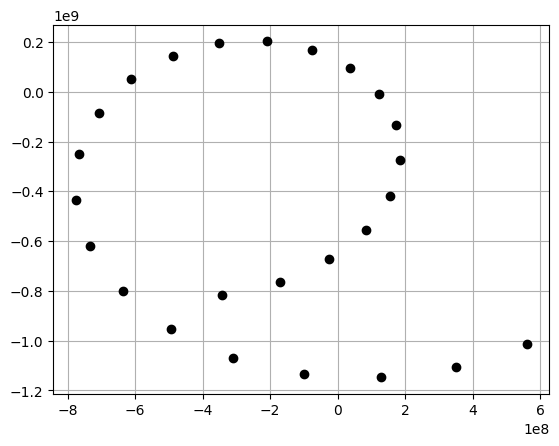

In [10]:
X = np.array(X)
rvec_sun = X[:3]
vvec_sun = X[3:]

mu = pc.constantes.mu_sun + pc.constantes.mu_jupiter
for i, j in enumerate(jds):
    rvec_sun = X[i, :3]
    vvec_sun = X[i, 3:]
    p, e, I, omegap, Omegap, f = orbital_elements(rvec_sun, vvec_sun, mu)
    plt.plot(rvec_sun[0], rvec_sun[1] , 'ko')
plt.grid()